In [1]:
!pip install -q kaggle

In [2]:
from google.colab import files
files.upload()

Saving kaggle (2).json to kaggle (2).json


{'kaggle (2).json': b'{"username":"rehabelsayed","key":"914faf30bf37385be6617d38d01a6130"}'}

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("Kaggle API is ready.")

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Kaggle API is ready.


In [4]:
!mkdir -p /content/gdm_dataset

!kaggle datasets download -d sumathisanthosh/gestational-diabetes-mellitus-gdm-data-set -p /content/gdm_dataset --unzip

print("Dataset downloaded and extracted.")

Dataset URL: https://www.kaggle.com/datasets/sumathisanthosh/gestational-diabetes-mellitus-gdm-data-set
License(s): CC-BY-NC-SA-4.0
100% 194k/194k [00:00<00:00, 118MB/s]

Dataset downloaded and extracted.


In [5]:
# =========================
# Cell 4: Imports
# =========================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [6]:
import os

base_path = "/content/gdm_dataset"

for root, dirs, files in os.walk(base_path):
    for file in files:
        print(os.path.join(root, file))

/content/gdm_dataset/Gestational Diabetic Dat Set.xlsx


In [7]:
# =========================
# Cell 5: Read Dataset
# =========================

excel_files = []

for root, dirs, files in os.walk("/content"):
    for file in files:
        if file.endswith((".xlsx", ".xls")):
            excel_files.append(os.path.join(root, file))

print("Excel files found:")
for i, file in enumerate(excel_files):
    print(i, "=>", file)

if len(excel_files) == 0:
    raise FileNotFoundError("No Excel file found. Please download the dataset first.")

file_name = excel_files[0]

df = pd.read_excel(file_name)

print("Dataset loaded successfully.")
print("Original shape:", df.shape)

df.head()

Excel files found:
0 => /content/gdm_dataset/Gestational Diabetic Dat Set.xlsx
Dataset loaded successfully.
Original shape: (3525, 17)


,Case Number,Age,No of Pregnancy,Gestation in previous Pregnancy,BMI,HDL,Family History,unexplained prenetal loss,Large Child or Birth Default,PCOS,Sys BP,Dia BP,OGTT,Hemoglobin,Sedentary Lifestyle,Prediabetes,Class Label(GDM /Non GDM)
0,1,22,2,1,NaN,55.0,0,0,0,0,102.0,69,NaN,12.0,0,0,0
1,2,26,2,1,NaN,53.0,0,0,0,0,101.0,63,NaN,12.4,0,0,0
2,3,29,1,0,NaN,50.0,0,0,0,0,118.0,79,NaN,14.3,0,0,0
3,4,28,2,1,NaN,51.0,0,0,0,0,99.0,70,NaN,15.0,0,0,0
4,5,21,2,1,NaN,52.0,0,0,0,0,116.0,65,NaN,15.0,0,0,0


In [8]:
# =========================
# Cell 6: Clean Column Names
# =========================

df.columns = (
    df.columns
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("/", "_")
    .str.replace("-", "_")
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
    .str.replace("__", "_")
)

print("Cleaned columns:")
for i, col in enumerate(df.columns):
    print(i, "=>", col)

df.head()

Cleaned columns:
0 => case_number
1 => age
2 => no_of_pregnancy
3 => gestation_in_previous_pregnancy
4 => bmi
5 => hdl
6 => family_history
7 => unexplained_prenetal_loss
8 => large_child_or_birth_default
9 => pcos
10 => sys_bp
11 => dia_bp
12 => ogtt
13 => hemoglobin
14 => sedentary_lifestyle
15 => prediabetes
16 => class_labelgdm_non_gdm


,case_number,age,no_of_pregnancy,gestation_in_previous_pregnancy,bmi,hdl,family_history,unexplained_prenetal_loss,large_child_or_birth_default,pcos,sys_bp,dia_bp,ogtt,hemoglobin,sedentary_lifestyle,prediabetes,class_labelgdm_non_gdm
0,1,22,2,1,NaN,55.0,0,0,0,0,102.0,69,NaN,12.0,0,0,0
1,2,26,2,1,NaN,53.0,0,0,0,0,101.0,63,NaN,12.4,0,0,0
2,3,29,1,0,NaN,50.0,0,0,0,0,118.0,79,NaN,14.3,0,0,0
3,4,28,2,1,NaN,51.0,0,0,0,0,99.0,70,NaN,15.0,0,0,0
4,5,21,2,1,NaN,52.0,0,0,0,0,116.0,65,NaN,15.0,0,0,0


In [9]:
for i, col in enumerate(df.columns):
    print(i, "=>", col)

0 => case_number
1 => age
2 => no_of_pregnancy
3 => gestation_in_previous_pregnancy
4 => bmi
5 => hdl
6 => family_history
7 => unexplained_prenetal_loss
8 => large_child_or_birth_default
9 => pcos
10 => sys_bp
11 => dia_bp
12 => ogtt
13 => hemoglobin
14 => sedentary_lifestyle
15 => prediabetes
16 => class_labelgdm_non_gdm


In [10]:
# =========================
# Cell 7: Basic Data Understanding
# =========================

target_col = "class_labelgdm_non_gdm"

print("Dataset shape:", df.shape)

print("\nTarget distribution:")
print(df[target_col].value_counts())

print("\nTarget percentage:")
print((df[target_col].value_counts(normalize=True) * 100).round(2))

missing_table = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percent": (df.isnull().sum() / len(df) * 100).round(2)
})

print("\nMissing values:")
display(missing_table)

print("\nDuplicated rows:")
print(df.duplicated().sum())

Dataset shape: (3525, 17)

Target distribution:
class_labelgdm_non_gdm
0    2153
1    1372
Name: count, dtype: int64

Target percentage:
class_labelgdm_non_gdm
0    61.08
1    38.92
Name: proportion, dtype: float64

Missing values:


,missing_count,missing_percent
case_number,0,0.00
age,0,0.00
no_of_pregnancy,0,0.00
gestation_in_previous_pregnancy,0,0.00
bmi,1081,30.67
hdl,1001,28.40
family_history,0,0.00
unexplained_prenetal_loss,0,0.00
large_child_or_birth_default,0,0.00
pcos,0,0.00



Duplicated rows:
0


In [11]:
# =========================
# Cell 8: Prepare Features and Target
# =========================

X = df.drop(columns=["case_number", target_col])
y = df[target_col]

# Convert features to numeric
for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors="coerce")

# Convert target to integer
y = pd.to_numeric(y, errors="coerce").astype(int)

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeatures used:")
print(X.columns.tolist())

print("\nTarget distribution:")
print(y.value_counts())

Features shape: (3525, 15)
Target shape: (3525,)

Features used:
['age', 'no_of_pregnancy', 'gestation_in_previous_pregnancy', 'bmi', 'hdl', 'family_history', 'unexplained_prenetal_loss', 'large_child_or_birth_default', 'pcos', 'sys_bp', 'dia_bp', 'ogtt', 'hemoglobin', 'sedentary_lifestyle', 'prediabetes']

Target distribution:
class_labelgdm_non_gdm
0    2153
1    1372
Name: count, dtype: int64


In [12]:
# =========================
# Cell 9: Train/Test Split
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("\nTrain target distribution:")
print(y_train.value_counts())

print("\nTest target distribution:")
print(y_test.value_counts())

X_train: (2820, 15)
X_test: (705, 15)

Train target distribution:
class_labelgdm_non_gdm
0    1722
1    1098
Name: count, dtype: int64

Test target distribution:
class_labelgdm_non_gdm
0    431
1    274
Name: count, dtype: int64


In [13]:
# =========================
# Cell 10: Train Models and Compare Train/Test Performance
# =========================

preprocessor = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("scaler", StandardScaler())
])

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

trained_models = {}
train_test_results = []

for model_name, model in models.items():

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)
    trained_models[model_name] = pipeline

    # Train prediction
    y_train_pred = pipeline.predict(X_train)
    y_train_proba = pipeline.predict_proba(X_train)[:, 1]

    # Test prediction
    y_test_pred = pipeline.predict(X_test)
    y_test_proba = pipeline.predict_proba(X_test)[:, 1]

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    train_auc = roc_auc_score(y_train, y_train_proba)
    test_auc = roc_auc_score(y_test, y_test_proba)

    train_test_results.append({
        "Model": model_name,

        "Train Accuracy": round(train_acc, 4),
        "Test Accuracy": round(test_acc, 4),
        "Accuracy Gap": round(train_acc - test_acc, 4),

        "Train Precision": round(precision_score(y_train, y_train_pred), 4),
        "Test Precision": round(precision_score(y_test, y_test_pred), 4),

        "Train Recall": round(recall_score(y_train, y_train_pred), 4),
        "Test Recall": round(recall_score(y_test, y_test_pred), 4),

        "Train F1": round(f1_score(y_train, y_train_pred), 4),
        "Test F1": round(f1_score(y_test, y_test_pred), 4),

        "Train AUC": round(train_auc, 4),
        "Test AUC": round(test_auc, 4),
        "AUC Gap": round(train_auc - test_auc, 4)
    })

    print(model_name, "trained and evaluated successfully.")

train_test_df = pd.DataFrame(train_test_results)
train_test_df

Logistic Regression trained and evaluated successfully.
Random Forest trained and evaluated successfully.
Gradient Boosting trained and evaluated successfully.


,Model,Train Accuracy,Test Accuracy,Accuracy Gap,Train Precision,Test Precision,Train Recall,Test Recall,Train F1,Test F1,Train AUC,Test AUC,AUC Gap
0,Logistic Regression,0.9759,0.9645,0.0113,0.9549,0.9462,0.9845,0.9635,0.9695,0.9548,0.9987,0.9971,0.0016
1,Random Forest,0.9993,0.9660,0.0333,0.9982,0.9496,1.0000,0.9635,0.9991,0.9565,1.0000,0.9978,0.0022
2,Gradient Boosting,0.9972,0.9660,0.0312,0.9955,0.9529,0.9973,0.9599,0.9964,0.9564,1.0000,0.9972,0.0028


In [14]:
# =========================
# Cell 11: Detailed Evaluation
# =========================

results = []

for model_name, pipeline in trained_models.items():
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    results.append({
        "Model": model_name,
        "Accuracy": round(acc, 4),
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "F1-score": round(f1, 4),
        "AUC": round(auc, 4)
    })

    print("=" * 60)
    print(model_name)
    print("=" * 60)

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    print("AUC:", round(auc, 4))
    print()

results_df = pd.DataFrame(results)
results_df

Logistic Regression
Confusion Matrix:
[[416  15]
 [ 10 264]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.97       431
           1       0.95      0.96      0.95       274

    accuracy                           0.96       705
   macro avg       0.96      0.96      0.96       705
weighted avg       0.96      0.96      0.96       705

AUC: 0.9971

Random Forest
Confusion Matrix:
[[417  14]
 [ 10 264]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.97       431
           1       0.95      0.96      0.96       274

    accuracy                           0.97       705
   macro avg       0.96      0.97      0.96       705
weighted avg       0.97      0.97      0.97       705

AUC: 0.9978

Gradient Boosting
Confusion Matrix:
[[418  13]
 [ 11 263]]

Classification Report:
              precision    recall  f1-score   support

           0      

,Model,Accuracy,Precision,Recall,F1-score,AUC
0,Logistic Regression,0.9645,0.9462,0.9635,0.9548,0.9971
1,Random Forest,0.9660,0.9496,0.9635,0.9565,0.9978
2,Gradient Boosting,0.9660,0.9529,0.9599,0.9564,0.9972


In [15]:
# =========================
# Cell 12: Select Final Model
# =========================

best_model_name = "Random Forest"
best_model = trained_models[best_model_name]

print("Final model selected:", best_model_name)

Final model selected: Random Forest


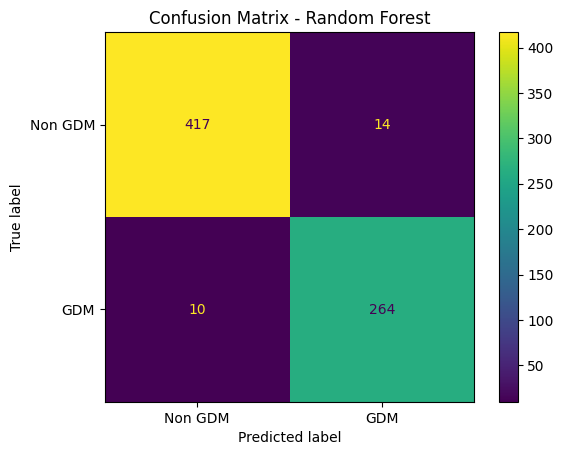

In [16]:
# =========================
# Cell 13: Confusion Matrix Plot
# =========================

y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non GDM", "GDM"]
)

disp.plot(values_format="d")
plt.title("Confusion Matrix - Random Forest")
plt.show()

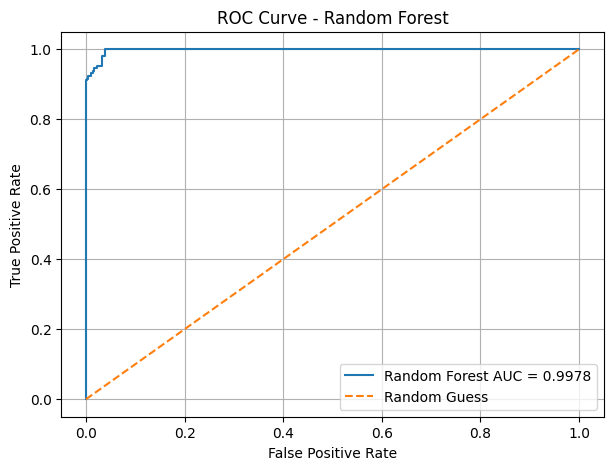

In [17]:
# =========================
# Cell 14: ROC Curve
# =========================

y_proba_best = best_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_proba_best)
auc_score = roc_auc_score(y_test, y_proba_best)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Random Forest AUC = {auc_score:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.grid(True)
plt.show()

,Feature,Importance
11,ogtt,0.277879
3,bmi,0.149745
14,prediabetes,0.104402
16,hdl_missing,0.100697
10,dia_bp,0.090423
9,sys_bp,0.066210
8,pcos,0.059448
2,gestation_in_previous_pregnancy,0.052986
4,hdl,0.027677
15,bmi_missing,0.018590


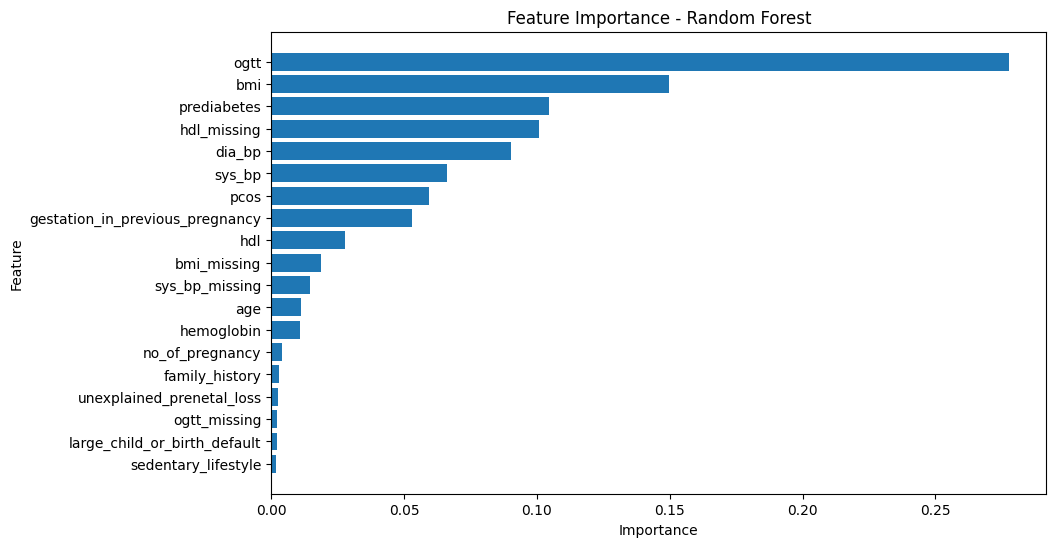

In [18]:
# =========================
# Cell 15: Feature Importance
# =========================

rf_model = best_model.named_steps["model"]
imputer = best_model.named_steps["preprocessor"].named_steps["imputer"]

original_features = list(X.columns)

missing_indicator_features = [
    original_features[i] + "_missing"
    for i in imputer.indicator_.features_
]

all_feature_names = original_features + missing_indicator_features

feature_importance = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

display(feature_importance)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance["Feature"], feature_importance["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance - Random Forest")
plt.gca().invert_yaxis()
plt.show()

In [19]:
# =========================
# Cell 16: Early GDM Risk Model Without OGTT
# =========================

X_early = X.drop(columns=["ogtt"])

X_train_early, X_test_early, y_train_early, y_test_early = train_test_split(
    X_early,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

early_preprocessor = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("scaler", StandardScaler())
])

early_rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42
)

early_model = Pipeline(steps=[
    ("preprocessor", early_preprocessor),
    ("model", early_rf_model)
])

early_model.fit(X_train_early, y_train_early)

y_pred_early = early_model.predict(X_test_early)
y_proba_early = early_model.predict_proba(X_test_early)[:, 1]

print("Early Model Without OGTT")
print("=" * 50)
print("Confusion Matrix:")
print(confusion_matrix(y_test_early, y_pred_early))

print("\nClassification Report:")
print(classification_report(y_test_early, y_pred_early))

print("Accuracy:", round(accuracy_score(y_test_early, y_pred_early), 4))
print("Precision:", round(precision_score(y_test_early, y_pred_early), 4))
print("Recall:", round(recall_score(y_test_early, y_pred_early), 4))
print("F1-score:", round(f1_score(y_test_early, y_pred_early), 4))
print("AUC:", round(roc_auc_score(y_test_early, y_proba_early), 4))

Early Model Without OGTT
Confusion Matrix:
[[418  13]
 [ 10 264]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.97       431
           1       0.95      0.96      0.96       274

    accuracy                           0.97       705
   macro avg       0.96      0.97      0.97       705
weighted avg       0.97      0.97      0.97       705

Accuracy: 0.9674
Precision: 0.9531
Recall: 0.9635
F1-score: 0.9583
AUC: 0.9975


,Feature,Importance
3,bmi,0.218967
15,hdl_missing,0.149249
10,dia_bp,0.146835
13,prediabetes,0.139639
2,gestation_in_previous_pregnancy,0.079122
9,sys_bp,0.074487
8,pcos,0.063516
14,bmi_missing,0.028335
4,hdl,0.026356
11,hemoglobin,0.020065


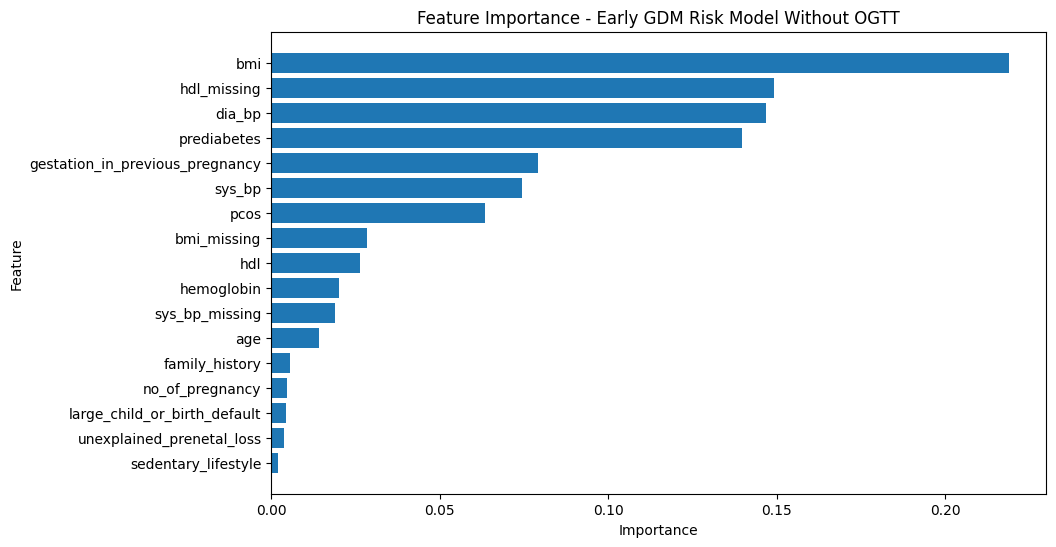

In [20]:
# =========================
# Cell 17: Feature Importance - Early Model
# =========================

early_rf = early_model.named_steps["model"]
early_imputer = early_model.named_steps["preprocessor"].named_steps["imputer"]

early_original_features = list(X_early.columns)

early_missing_indicator_features = [
    early_original_features[i] + "_missing"
    for i in early_imputer.indicator_.features_
]

early_all_features = early_original_features + early_missing_indicator_features

early_feature_importance = pd.DataFrame({
    "Feature": early_all_features,
    "Importance": early_rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

display(early_feature_importance)

plt.figure(figsize=(10, 6))
plt.barh(early_feature_importance["Feature"], early_feature_importance["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance - Early GDM Risk Model Without OGTT")
plt.gca().invert_yaxis()
plt.show()

In [21]:
# =========================
# Cell 18: Save Models
# =========================

joblib.dump(best_model, "gdm_clinical_model_with_ogtt.pkl")
joblib.dump(list(X.columns), "gdm_clinical_features_with_ogtt.pkl")

joblib.dump(early_model, "early_gdm_risk_model_without_ogtt.pkl")
joblib.dump(list(X_early.columns), "early_gdm_features_without_ogtt.pkl")

print("Models saved successfully.")
print("1. gdm_clinical_model_with_ogtt.pkl")
print("2. gdm_clinical_features_with_ogtt.pkl")
print("3. early_gdm_risk_model_without_ogtt.pkl")
print("4. early_gdm_features_without_ogtt.pkl")

Models saved successfully.
1. gdm_clinical_model_with_ogtt.pkl
2. gdm_clinical_features_with_ogtt.pkl
3. early_gdm_risk_model_without_ogtt.pkl
4. early_gdm_features_without_ogtt.pkl


In [22]:
# =========================
# Cell 19: Prediction Function - Early GDM Risk
# =========================

def predict_early_gdm_risk(patient_data):
    """
    Predict early risk of Gestational Diabetes Mellitus without OGTT.
    This model is for screening support, not final diagnosis.
    """

    input_df = pd.DataFrame([patient_data])

    for col in X_early.columns:
        if col not in input_df.columns:
            input_df[col] = None

    input_df = input_df[X_early.columns]

    prediction = early_model.predict(input_df)[0]
    probability = early_model.predict_proba(input_df)[0][1]

    if probability < 0.40:
        risk_level = "Low Risk"
    elif probability < 0.70:
        risk_level = "Moderate Risk"
    else:
        risk_level = "High Risk"

    return {
        "prediction": int(prediction),
        "prediction_label": "GDM Risk" if prediction == 1 else "Non GDM Risk",
        "gdm_probability": round(probability * 100, 2),
        "risk_level": risk_level
    }

In [23]:
# =========================
# Cell 20: Test Prediction on New Patient
# =========================

sample_patient = {
    "age": 30,
    "no_of_pregnancy": 2,
    "gestation_in_previous_pregnancy": 1,
    "bmi": 31.5,
    "hdl": 45,
    "family_history": 1,
    "unexplained_prenetal_loss": 0,
    "large_child_or_birth_default": 0,
    "pcos": 1,
    "sys_bp": 125,
    "dia_bp": 82,
    "hemoglobin": 12.4,
    "sedentary_lifestyle": 1,
    "prediabetes": 1
}

result = predict_early_gdm_risk(sample_patient)

print("Prediction:", result["prediction_label"])
print("GDM Probability:", result["gdm_probability"], "%")
print("Risk Level:", result["risk_level"])

Prediction: GDM Risk
GDM Probability: 62.34 %
Risk Level: Moderate Risk


In [24]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(best_model, X, y, cv=5, scoring='accuracy')

print("Cross Validation Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())

Cross Validation Scores: [0.96879433 1.         0.9929078  1.         0.85390071]
Mean CV Accuracy: 0.9631205673758865


In [25]:
train_acc = best_model.score(X_train, y_train)
test_acc = best_model.score(X_test, y_test)

print("Train Accuracy:", round(train_acc,4))
print("Test Accuracy:", round(test_acc,4))

Train Accuracy: 0.9993
Test Accuracy: 0.966


In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

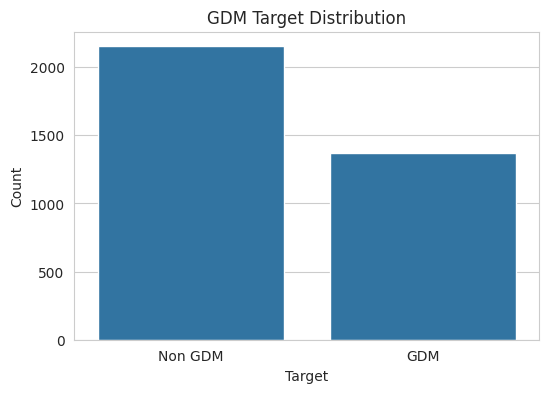

In [27]:
plt.figure(figsize=(6,4))

sns.countplot(x=y)

plt.title("GDM Target Distribution")
plt.xlabel("Target")
plt.ylabel("Count")

plt.xticks([0,1], ["Non GDM", "GDM"])

plt.show()

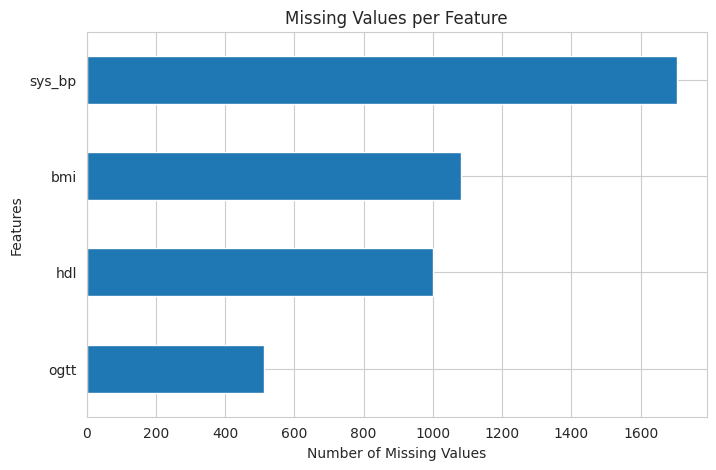

In [29]:
missing_values = df.isnull().sum()

missing_values = missing_values[missing_values > 0]

plt.figure(figsize=(8,5))

missing_values.sort_values().plot(kind='barh')

plt.title("Missing Values per Feature")
plt.xlabel("Number of Missing Values")
plt.ylabel("Features")

plt.show()

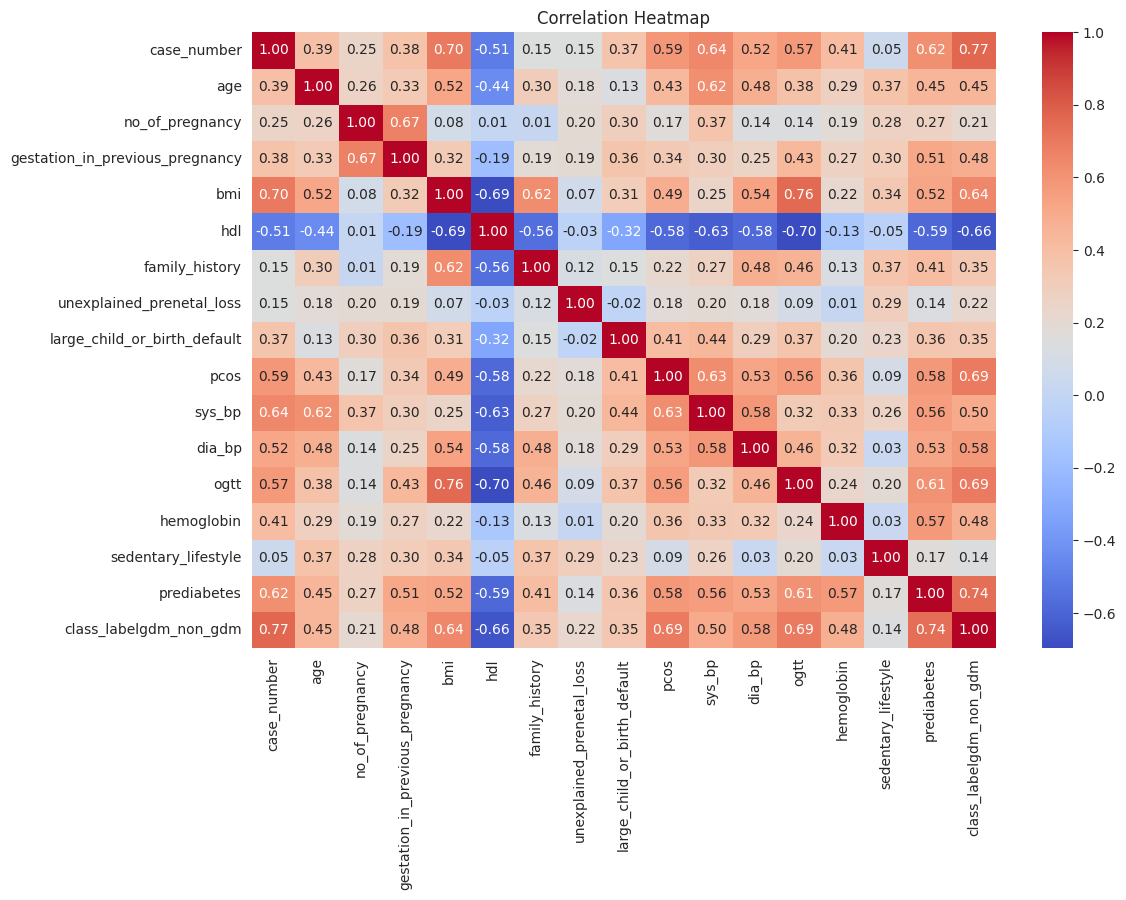

In [31]:
plt.figure(figsize=(12,8))

corr_matrix = df.corr(numeric_only=True)

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

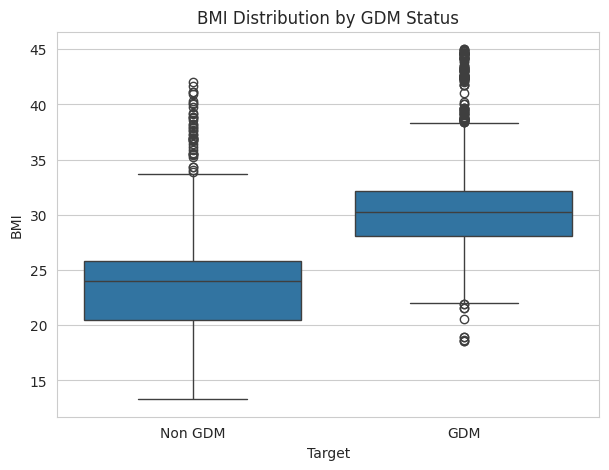

In [33]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x=df[target_col],
    y=df["bmi"]
)

plt.xticks([0,1], ["Non GDM", "GDM"])

plt.title("BMI Distribution by GDM Status")
plt.xlabel("Target")
plt.ylabel("BMI")

plt.show()

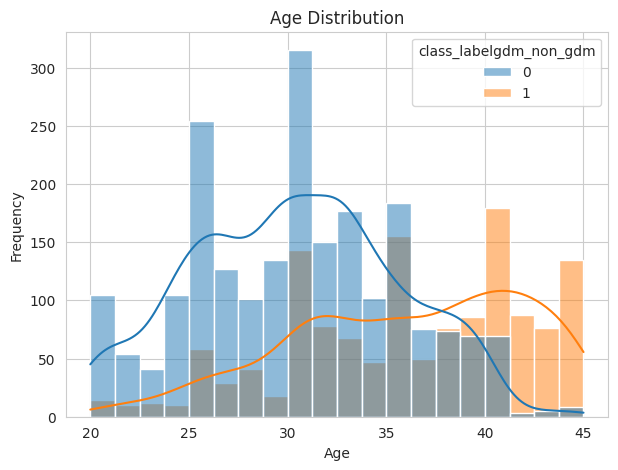

In [35]:
plt.figure(figsize=(7,5))

sns.histplot(
    data=df,
    x="age",
    hue=target_col,
    kde=True,
    bins=20
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

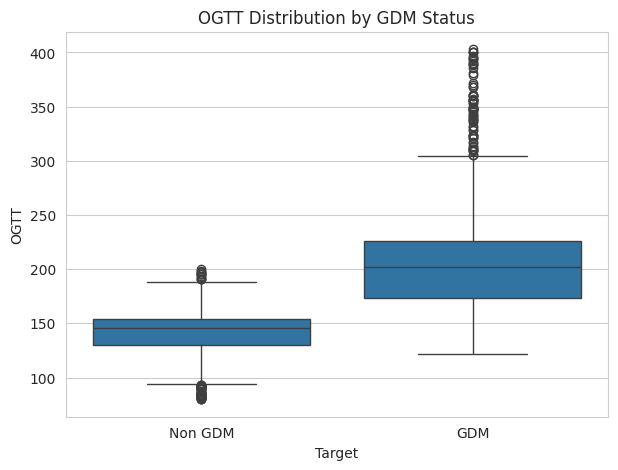

In [37]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x=df[target_col],
    y=df["ogtt"]
)

plt.xticks([0,1], ["Non GDM", "GDM"])

plt.title("OGTT Distribution by GDM Status")
plt.xlabel("Target")
plt.ylabel("OGTT")

plt.show()

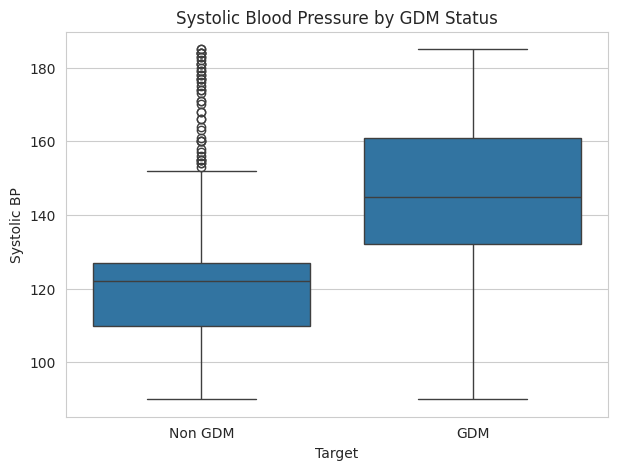

In [39]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x=df[target_col],
    y=df["sys_bp"]
)

plt.xticks([0,1], ["Non GDM", "GDM"])

plt.title("Systolic Blood Pressure by GDM Status")
plt.xlabel("Target")
plt.ylabel("Systolic BP")

plt.show()